In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk

from netket.experimental.dynamics import RK45, Heun

from callbacks import (
    get_tdvp_monitor_callback,
    get_umbrella_monitor_callback,
)

from logger import Logger

In [46]:
import jax.numpy as jnp
import numpy as np
import flax.linen as nn

N = 4
hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

def get_vstate(n_samples):
    # model = nk.models.RBM(param_dtype=complex, alpha=1)
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)
    graph = nk.graph.Chain(N, pbc=True)
    model = nk.models.RBMSymm(
        alpha=1,
        param_dtype=complex,
        use_visible_bias=True,
        hidden_bias_init=nn.initializers.normal(1e-4),
        visible_bias_init=nn.initializers.normal(1e-4),
        kernel_init=nn.initializers.normal(1e-4),
        symmetries=graph.translation_group()
    )
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100
    )
    eps_params = vstate.parameters.copy()
    K = 3
    a = jnp.array([-K], dtype=eps_params['visible_bias'].dtype)
    eps_params["visible_bias"] = a
    vstate.parameters = eps_params.copy()
    
    # Thermalize
    for i in range(1000):
        vstate.sample(n_samples=n_samples)
    return vstate


vstate = get_vstate(2**9)
print("Single peak state")
print(vstate.to_array())

Single peak state
[3.77508828e-11+6.89796797e-19j 1.52297931e-08-1.28460281e-16j
 1.52297931e-08-1.28460281e-16j 6.14413706e-06-2.08451386e-13j
 1.52297931e-08-1.28460281e-16j 6.14413688e-06+4.54554088e-14j
 6.14413706e-06-2.08451386e-13j 2.47872175e-03-4.18379414e-11j
 1.52297931e-08-1.28460281e-16j 6.14413706e-06-2.08451386e-13j
 6.14413688e-06+4.54554088e-14j 2.47872175e-03-4.18379414e-11j
 6.14413706e-06-2.08451386e-13j 2.47872175e-03-4.18379414e-11j
 2.47872175e-03-4.18379414e-11j 9.99987712e-01+1.38424683e-09j]


In [47]:
graph = nk.graph.Chain(N, pbc=True)
hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=1., J=-1.)
n_samples_list = [2**i for i in range(9,15)]

for i in range(N):
    string = ["I"]*N
    string[i] = "Z"
    if i==0:
        sigma_zs=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
    else:
        sigma_zs+=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("sigma_z", "Mean"),
    ("sigma_z", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)


def measure_sigma_z(step, log, driver):
    log['sigma_z'] = driver.state.expect(sigma_zs)
    return True

# Exact dynamics

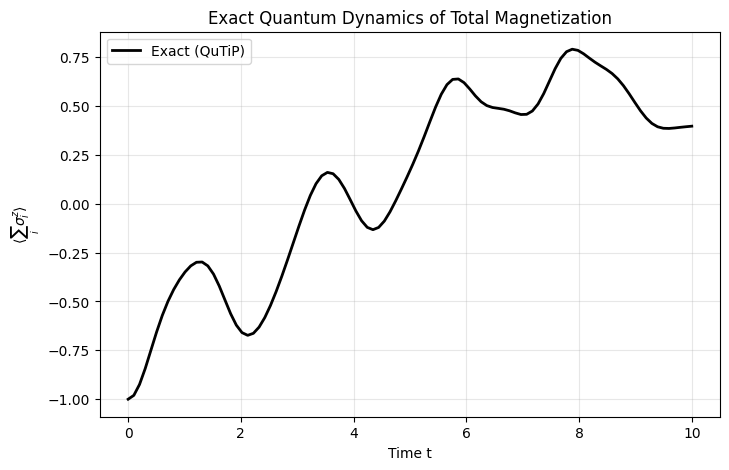

Initial magnetization: -0.999988
Final magnetization: 0.396429


In [10]:
import qutip as qt


# Time evolution parameters
T = 10.00
J = 1.0
h = 1.0
times_exact = np.linspace(0.0, T, 100)
N = 4
if N <=4:
    # Get the Hamiltonian matrix from netket
    H_matrix = hamiltonian.to_dense()

    # Convert to QuTiP Qobj
    H_qutip = qt.Qobj(H_matrix)

    # Get initial state from vstate
    psi0_array = vstate.to_array()
    psi0_qutip = qt.Qobj(psi0_array)
    psi0_qutip = psi0_qutip.unit()  # Normalize

    # Create total magnetization operator (sum of Z_i)
    # Convert netket operator to matrix
    sigma_z_matrix = sigma_zs.to_dense() * N  # Multiply by N since sigma_zs is normalized by 1/N

    # Convert to QuTiP
    Z_total_qutip = qt.Qobj(sigma_z_matrix)

    # Evolve the state and calculate expectation values
    magnetizations_exact = []
    for t in times_exact:
        # Evolve state
        psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
        # Calculate expectation value
        mag = qt.expect(Z_total_qutip, psi_t)
        magnetizations_exact.append(mag / 4)
else:
    times_exact = np.load(f"data/TFIM_exact_Z/times_{N}_h{h:.2f}_J{J:.2f}_T{T:.2f}.npy")
    magnetizations_exact = np.load(f"data/TFIM_exact_Z/exactZ_{N}_h{h:.2f}_J{J:.2f}_T{T:.2f}.npy")

# Plot the exact dynamics
plt.figure(figsize=(8, 5))
plt.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='Exact (QuTiP)')
plt.xlabel('Time t')
plt.ylabel(r'$\langle \sum_i \sigma^z_i \rangle$')
plt.title('Exact Quantum Dynamics of Total Magnetization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial magnetization: {np.real(magnetizations_exact[0]):.6f}")
print(f"Final magnetization: {np.real(magnetizations_exact[-1]):.6f}")

## Standard Dynamics

In [61]:
from schmitt_tdvp import TDVPSchmitt

def fit(n_samples_tvmc):    
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"fixed_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook
    
    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc)
    print(vstate.expect(sigma_zs))
    callbacks = []
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    integrator = RK45(1e-3, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    # integrator = Heun(1e-2)
    tvmc_kwargs = {}
    driver = TDVPSchmitt(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
        **tvmc_kwargs,
    )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [52]:
for n_samples_tvmc in n_samples_list:
    fit(n_samples_tvmc)


File not found


-1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]


  0%|          | 0.00/0.50 [00:00<?, ?it/s]

KeyboardInterrupt: 

Restored: True
Restored: True
Restored: True
Restored: True
Restored: True
Restored: True


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


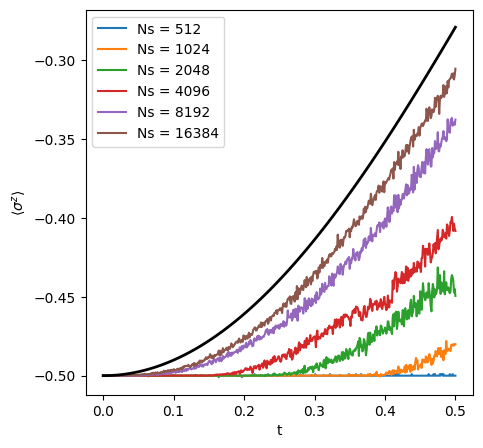

In [ ]:
fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"fixed_{n_samples}"
    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())
    
    ax_z.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = f"Ns = {n_samples}")
   
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")
ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='ED')


In [48]:
from schmitt_tdvp_randomized_bridge import TDVPSchmittRandomizedBridge

def fit_bridge(n_samples_tvmc, q1, q2):
    T = 10
    # q1 = 0.2
    # q2 = 0.0
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}_q1_{q1:.2f}_q2_{q2:.2f}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc)
    print(vstate.expect(sigma_zs))
    callbacks = [ ]
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)

    integrator = RK45(1e-3, adaptive=True, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    integrator = Heun(1e-3)
    tvmc_kwargs = {}
    driver = TDVPSchmittRandomizedBridge(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        q1=q1,
        q2=q2,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)



In [7]:
for n_samples_tvmc in [2**10]:
    fit_bridge(n_samples_tvmc, q1=0.1, q2=0.5)

-1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]


  0%|          | 0.00/10.0 [00:00<?, ?it/s]

()


KeyboardInterrupt: 

File not found
Restored:
Restored:
File not found
File not found
File not found


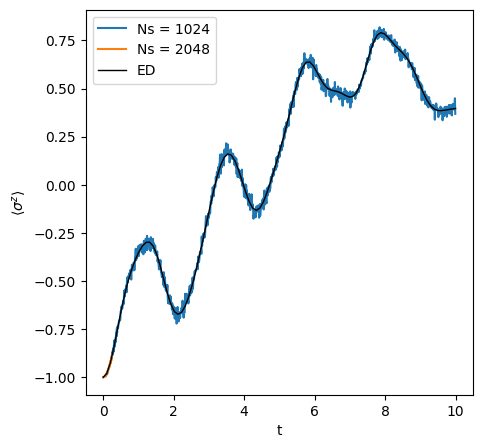

In [60]:
fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
# exact_exp_name = f"fixed_{2**10}"
# save_path = f"./data/TFIM_EPS_{N}/{exact_exp_name}/"
# logger = Logger(path=save_path, fields=fields_to_track)
# print("Restored:", logger.restore())
# exact_val = logger.data["sigma_z"]["Mean"]
N = 4
q1 = 0.1
q2 = 0.5
T = 10
for n_samples in n_samples_list[:]:
    exp_name = f"bridge_{n_samples}_q1_{q1:.2f}_q2_{q2:.2f}_T_{T:.2f}"
    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        print("Restored:")
        ax_z.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = f"Ns = {n_samples}", zorder=-1)
        ax_z.set_xlabel("t")
        ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")

ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=1, label='ED')
ax_z.legend()

# ax_z.set_xlim(0,2)
# ax_z.set_ylim(-1,-0.95)

Restored: True


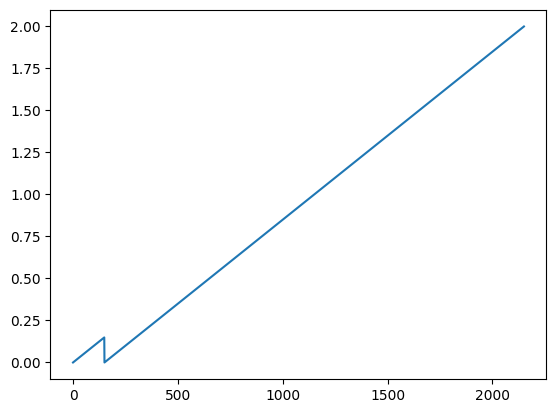

In [29]:
n_samples= 2**9
exp_name = f"bridge_{n_samples}"
save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())
plt.plot(logger.data["t"]["values"])

In [ ]:
logger.data["sigma_z"]["Mean"]

NameError: name 'logger' is not defined

Restored: True


/tmp/ipykernel_1548109/2085383348.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_snr.legend(loc="best")
/tmp/ipykernel_1548109/2085383348.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_snrF.legend(loc="best")


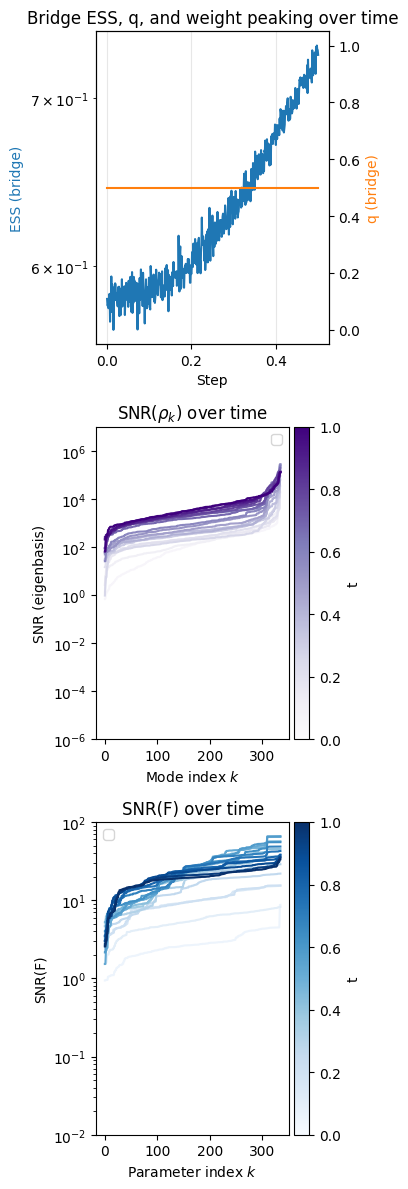

In [ ]:
n_samples_tvmc = 2**12
fig, (ax_essq,ax_snr,ax_snrF) = plt.subplots(3, 1, figsize=(4, 12))
exp_name = f"bridge_{n_samples_tvmc}"
save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())

x_vals = logger.data["t"]["values"]
ess_vals = logger.data["ess_bridge"]["values"]
q_vals = logger.data["q_bridge"]["values"]
if ess_vals and q_vals:

    ax_right = ax_essq.twinx()
    (line1,) = ax_essq.plot(
        x_vals, ess_vals, color="tab:blue", label="ESS (bridge)"
    )
    # Also plot max_weight_over_mean on left axis
    (line2,) = ax_right.plot(
        x_vals, q_vals, color="tab:orange", label="q (bridge)"
    )

    ax_essq.set_xlabel("Step")
    ax_essq.set_ylabel("ESS (bridge)", color="tab:blue")
    ax_right.set_ylabel("q (bridge)", color="tab:orange")
    ax_essq.set_yscale('log')
    ax_right.set_ylim(-0.05, 1.05)
    ax_essq.grid(True, alpha=0.3)
    ax_essq.set_title("Bridge ESS, q, and weight peaking over time")

    lines = [line1, line2]
    labels = [l.get_label() for l in lines]

# Top-left: SNR (eigenbasis) sorted curves with log y; add median and min lines
snr_len = len(logger.data.get("snr", {}).get("values", []))
cmap_snr = plt.get_cmap("Purples")
# Normalize step index to [0,1] for colorbar
norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
for i in range(snr_len):
    snr_data = np.array(logger.data["snr"]["values"][i]).flatten()
    frac = 0.0 if snr_len <= 1 else i / (snr_len - 1)
    snr_data = np.nan_to_num(snr_data, 0.)
    ax_snr.plot(np.sort(snr_data), color=cmap_snr(norm_frac(frac)))
# if len(snr_min_series) > 0:
#     ax_snr.axhline(np.array(snr_min_series)[-1], color="gray", linestyle=":", label="min")
ax_snr.set_xlabel(r"Mode index $k$")
ax_snr.set_ylabel("SNR (eigenbasis)")
ax_snr.set_title(rf"SNR($\rho_k$) over time")
ax_snr.set_yscale("log")
ax_snr.set_ylim([1e-6, 1e7])
ax_snr.legend(loc="best")
# Add colorbar for normalized step [0,1]
sm_snr = plt.cm.ScalarMappable(cmap=cmap_snr, norm=norm_frac)
sm_snr.set_array([])
fig.colorbar(sm_snr, ax=ax_snr, pad=0.02, label="t")

# Top-middle: SNR(F) sorted curves with log y; add median and min lines
snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
cmap_snrF = plt.get_cmap("Blues")
for i in range(snrF_len):
    snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
    snr_F_data = np.nan_to_num(snr_F_data, 0.)
    frac = 0.0 if snrF_len <= 1 else i / (snrF_len - 1)
    ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
# if len(snrF_min_series) > 0:
#     ax_snrF.axhline(np.array(snrF_min_series)[-1], color="gray", linestyle=":", label="min")
ax_snrF.set_xlabel(r"Parameter index $k$")
ax_snrF.set_ylabel("SNR(F)")
ax_snrF.set_title(rf"SNR(F) over time")
ax_snrF.set_yscale("log")
ax_snrF.set_ylim([1e-2, 1e2])
ax_snrF.legend(loc="best")
# Add colorbar for normalized step [0,1]
sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
sm_snrF.set_array([])
fig.colorbar(sm_snrF, ax=ax_snrF, pad=0.02, label="t")
plt.tight_layout()



Restored: True


NameError: name 'norm_frac' is not defined

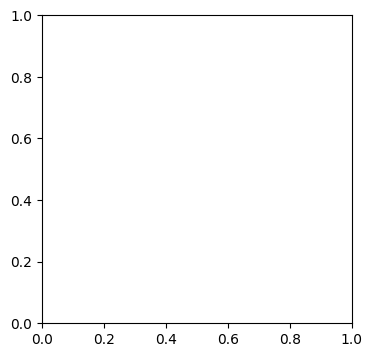

In [ ]:
n_samples_tvmc = 2**12
fig, ax_snrF = plt.subplots(1, 1, figsize=(4, 4))
exp_name = f"fixed_{n_samples_tvmc}"
save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())

# Top-middle: SNR(F) sorted curves with log y; add median and min lines
snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
cmap_snrF = plt.get_cmap("Blues")
for i in range(snrF_len):
    snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
    snr_F_data = np.nan_to_num(snr_F_data, 0.)
    frac = 0.0 if snrF_len <= 1 else i / (snrF_len - 1)
    ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
# if len(snrF_min_series) > 0:
ax_snrF.set_xlabel(r"Parameter index $k$")
ax_snrF.set_ylabel("SNR(F)")
ax_snrF.set_title(rf"SNR(F) over time")
ax_snrF.set_yscale("log")
ax_snrF.set_ylim([1e-2, 1e2])
ax_snrF.legend(loc="best")
# Add colorbar for normalized step [0,1]
sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
sm_snrF.set_array([])
fig.colorbar(sm_snrF, ax=ax_snrF, pad=0.02, label="t")
plt.tight_layout()

# Using the exact QGT

In [ ]:
from schmitt_tdvp_bridge_exact_qgt import TDVPSchmittBridgeExactQGT

def fit_bridge(n_samples_tvmc):
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_EPS_{N}_EXACT_QGT/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc)
    print(vstate.expect(sigma_zs))
    callbacks = [ ]
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)

    integrator = RK45(1e-3, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    driver = TDVPSchmittBridgeExactQGT(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        q=0.5,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

fit_bridge(2**12)

-5.00e-01+0.00e+00j ± nan [σ²=0.0e+00]


100%|██████████| 0.50/0.50 [00:33<00:00, 67.2s/it, n=500, Generator=0.096-0.025j ± 0.025 [σ²=2.6e+00]]      


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 33.631                                                                                                   │
│ ├── (1.1%) | MCState.expect : 0.356 s                                                                           │
│ ├── (18.5%) | MCState.sample : 6.205 s                                                                          │
│ │   └── (69.2%) | sampling n_discarded samples : 4.292 s                                                        │
│ ├── (9.4%) | QGTJacobian_DefaultConstructor : 3.164 s                                                           │
│ │   └── (61.4%) | jacobian : 1.944 s                                                                            │
│ └── (15.2%) | _impl : 5.108 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

File not found
Restored: False
File not found
Restored: False
File not found
Restored: False
Restored: True
File not found
Restored: False
File not found
Restored: False


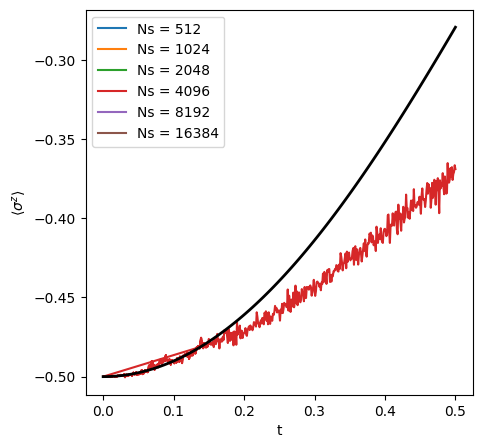

In [ ]:
fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"bridge_{n_samples}"
    save_path = f"./data/TFIM_EPS_{N}_EXACT_QGT/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())
    
    ax_z.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = f"Ns = {n_samples}")
   
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")
ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='ED')


In [ ]:
from schmitt_tdvp_bridge import TDVPSchmittBridge
from gaussian_state import EpsilonState

def get_vstate_eps(n_samples):
    model = nk.models.RBM(param_dtype=complex, alpha=1)
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)
    model = EpsilonState(
        s0= (1,-1,-1,-1)
    )
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100
    )
    # Thermalize
    for i in range(100):
        vstate.sample(n_samples=n_samples)
    return vstate

def fit_bridge(n_samples_tvmc):
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_PFAFF/EPS_{N}/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate_eps(n_samples_tvmc)
    print(vstate.expect(sigma_zs))
    callbacks = []
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)

    integrator = RK45(1e-3, adaptive=True, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    driver = TDVPSchmittBridge(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        q=0.5,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)
fit_bridge(2**10)


File not found
0.329+0.000j ± 0.011 [σ²=1.2e-01]


 13%|█▎        | 0.06/0.50 [06:15<43:27, 5.96ks/it, n=85, Generator=0.002-0.008j ± 0.011 [σ²=1.3e-01]]    


KeyboardInterrupt: 

File not found
Restored: False
Restored: True
File not found
Restored: False
File not found
Restored: False
File not found
Restored: False
File not found
Restored: False


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


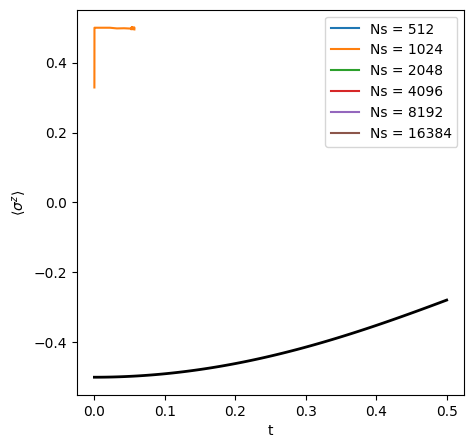

In [ ]:
fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"bridge_{n_samples}"
    save_path = f"./data/TFIM_PFAFF/EPS_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())
    
    ax_z.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = f"Ns = {n_samples}")
   
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")
ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='ED')